In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Import necessary packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import math


In [ ]:

# read csv
# Replace '/content/sample_data/grades_db(Assignment).csv' with the path to your CSV file
df = pd.read_csv('/content/sample_data/grades_db(Assignment).csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,school,country,sex,address,famsize,Pstatus,age,Medu,Fedu,Mjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,Grade
0,MS,UK,Male,R,GT3,T,18.0,3,2,services,...,yes,no,2,3,1,2,2,5,0,0
1,MS,US,Female,R,LE3,A,18.0,4,2,teacher,...,yes,yes,5,3,1,1,1,5,0,0
2,MS,UK,Female,U,GT3,T,19.0,1,1,at_home,...,no,no,5,5,5,2,3,2,0,0
3,MS,UK,Ma,U,GT3,T,16.0,1,1,at_home,...,no,yes,5,4,5,4,5,3,0,0
4,MS,US,Male,U,GT3,T,17.0,2,2,other,...,no,yes,1,2,1,2,3,5,0,0


# Understand data structures

### Descriptive analysis of data

In [ ]:
print("===== Dataset Info =====")
print(df.info())

===== Dataset Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 658 entries, 0 to 657
Data columns (total 32 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      658 non-null    object 
 1   country     658 non-null    object 
 2   sex         658 non-null    object 
 3   address     655 non-null    object 
 4   famsize     658 non-null    object 
 5   Pstatus     658 non-null    object 
 6   age         657 non-null    float64
 7   Medu        658 non-null    int64  
 8   Fedu        658 non-null    int64  
 9   Mjob        658 non-null    object 
 10  Fjob        658 non-null    object 
 11  reason      658 non-null    object 
 12  guardian    658 non-null    object 
 13  traveltime  658 non-null    int64  
 14  studytime   658 non-null    int64  
 15  failures    658 non-null    int64  
 16  schoolsup   658 non-null    object 
 17  famsup      658 non-null    object 
 18  paid        658 non-null    object 
 19  acti

In [ ]:
print(df.head())

  school country     sex address famsize Pstatus   age  Medu  Fedu      Mjob  \
0     MS      UK    Male       R     GT3       T  18.0     3     2  services   
1     MS      US  Female       R     LE3       A  18.0     4     2   teacher   
2     MS      UK  Female       U     GT3       T  19.0     1     1   at_home   
3     MS      UK      Ma       U     GT3       T  16.0     1     1   at_home   
4     MS      US    Male       U     GT3       T  17.0     2     2     other   

   ... internet romantic famrel  freetime  goout  Dalc Walc health absences  \
0  ...      yes       no      2         3      1     2    2      5        0   
1  ...      yes      yes      5         3      1     1    1      5        0   
2  ...       no       no      5         5      5     2    3      2        0   
3  ...       no      yes      5         4      5     4    5      3        0   
4  ...       no      yes      1         2      1     2    3      5        0   

  Grade  
0     0  
1     0  
2     0  
3   

In [ ]:
print("\n===== Variable Types =====")
print(df.dtypes.value_counts())


===== Variable Types =====
object     18
int64      13
float64     1
Name: count, dtype: int64


In [ ]:
print("\n===== Descriptive Statistics =====")
print(df.describe(include='all').transpose())


===== Descriptive Statistics =====
            count unique     top freq       mean       std   min   25%   50%  \
school        658      2      GP  429        NaN       NaN   NaN   NaN   NaN   
country       658      3      UK  601        NaN       NaN   NaN   NaN   NaN   
sex           658      5  Female  380        NaN       NaN   NaN   NaN   NaN   
address       655      3       U  452        NaN       NaN   NaN   NaN   NaN   
famsize       658      2     GT3  465        NaN       NaN   NaN   NaN   NaN   
Pstatus       658      2       T  578        NaN       NaN   NaN   NaN   NaN   
age         657.0    NaN     NaN  NaN  16.751903  1.216352  15.0  16.0  17.0   
Medu        658.0    NaN     NaN  NaN   2.510638  1.135041   0.0   2.0   2.0   
Fedu        658.0    NaN     NaN  NaN   2.302432  1.101276   0.0   1.0   2.0   
Mjob          658      5   other  261        NaN       NaN   NaN   NaN   NaN   
Fjob          658      5   other  373        NaN       NaN   NaN   NaN   NaN   
reas

## Missing value handling

In [ ]:
print("\n===== Missing Values =====")
print(df.isnull().sum()[df.isnull().sum() > 0])


===== Missing Values =====
address    3
age        1
dtype: int64


In [ ]:
# Fill missing 'address' values with the mode
df['address'].fillna(df['address'].mode()[0], inplace=True)

# Fill missing 'age' values with the median
df['age'].fillna(df['age'].median(), inplace=True)

print("\n===== Missing Values After Imputation =====")
print(df.isnull().sum()[df.isnull().sum() > 0])


===== Missing Values After Imputation =====
Series([], dtype: int64)


/tmp/ipython-input-1993917420.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['address'].fillna(df['address'].mode()[0], inplace=True)
/tmp/ipython-input-1993917420.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

## Outlier handling

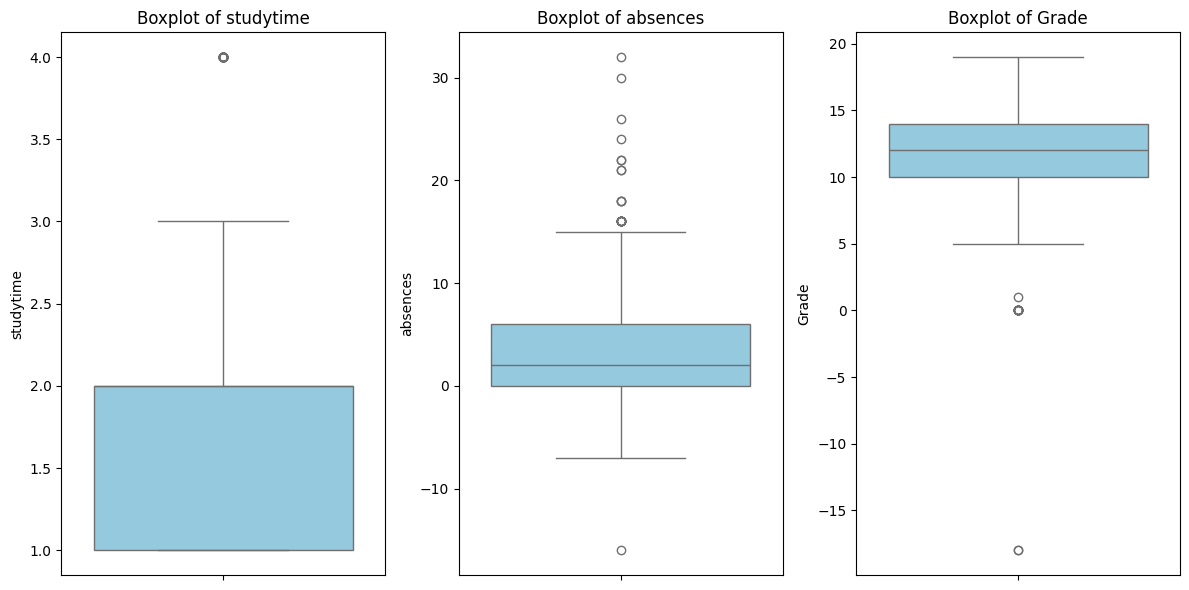

In [ ]:
# Boxplots for potential outliers (e.g., absences, studytime, Grade)
plt.figure(figsize=(12,6))
for i, col in enumerate(['studytime', 'absences', 'Grade']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

In [ ]:
# Outlier Treatment using IQR
# Identify outliers in 'absences', 'studytime', and 'Grade'
outlier_cols = ['absences', 'studytime', 'Grade']

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Replace outliers with the median
    median_val = df[col].median()
    df.loc[(df[col] < lower_bound) | (df[col] > upper_bound), col] = median_val


print("\n===== Outliers Treated (Replaced with Median) =====")
print(df[outlier_cols].describe())


===== Outliers Treated (Replaced with Median) =====
         absences   studytime       Grade
count  658.000000  658.000000  658.000000
mean     3.059271    1.823708   12.193009
std      3.523068    0.668434    2.615516
min     -7.000000    1.000000    5.000000
25%      0.000000    1.000000   10.000000
50%      2.000000    2.000000   12.000000
75%      4.000000    2.000000   14.000000
max     15.000000    3.000000   19.000000


## Data classification: numerical and categorical variables

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("===== Numeric Variables =====")
print(numeric_cols)

print("\n===== Categorical Variables =====")
print(categorical_cols)

===== Numeric Variables =====
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'Grade']

===== Categorical Variables =====
['school', 'country', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


## Calculate skewness and kurtosis

In [ ]:
print("\n===== Skewness and Kurtosis of Numeric Variables =====")
print(df[numeric_cols].skew())
print(df[numeric_cols].kurtosis())


===== Skewness and Kurtosis of Numeric Variables =====
age           0.406685
Medu         -0.023245
Fedu          0.210152
traveltime    1.244269
studytime     0.219078
failures      3.104212
famrel       -1.102780
freetime     -0.824833
goout        -0.746442
Dalc          2.140493
Walc          0.633930
health       -0.513088
absences      1.151688
Grade         0.251700
dtype: float64
age           0.066742
Medu         -1.264182
Fedu         -1.096664
traveltime    1.119205
studytime    -0.791288
failures      9.925005
famrel        1.347292
freetime      2.952431
goout         3.196055
Dalc          4.323383
Walc         -0.770072
health       -1.105578
absences      0.806394
Grade        -0.369304
dtype: float64


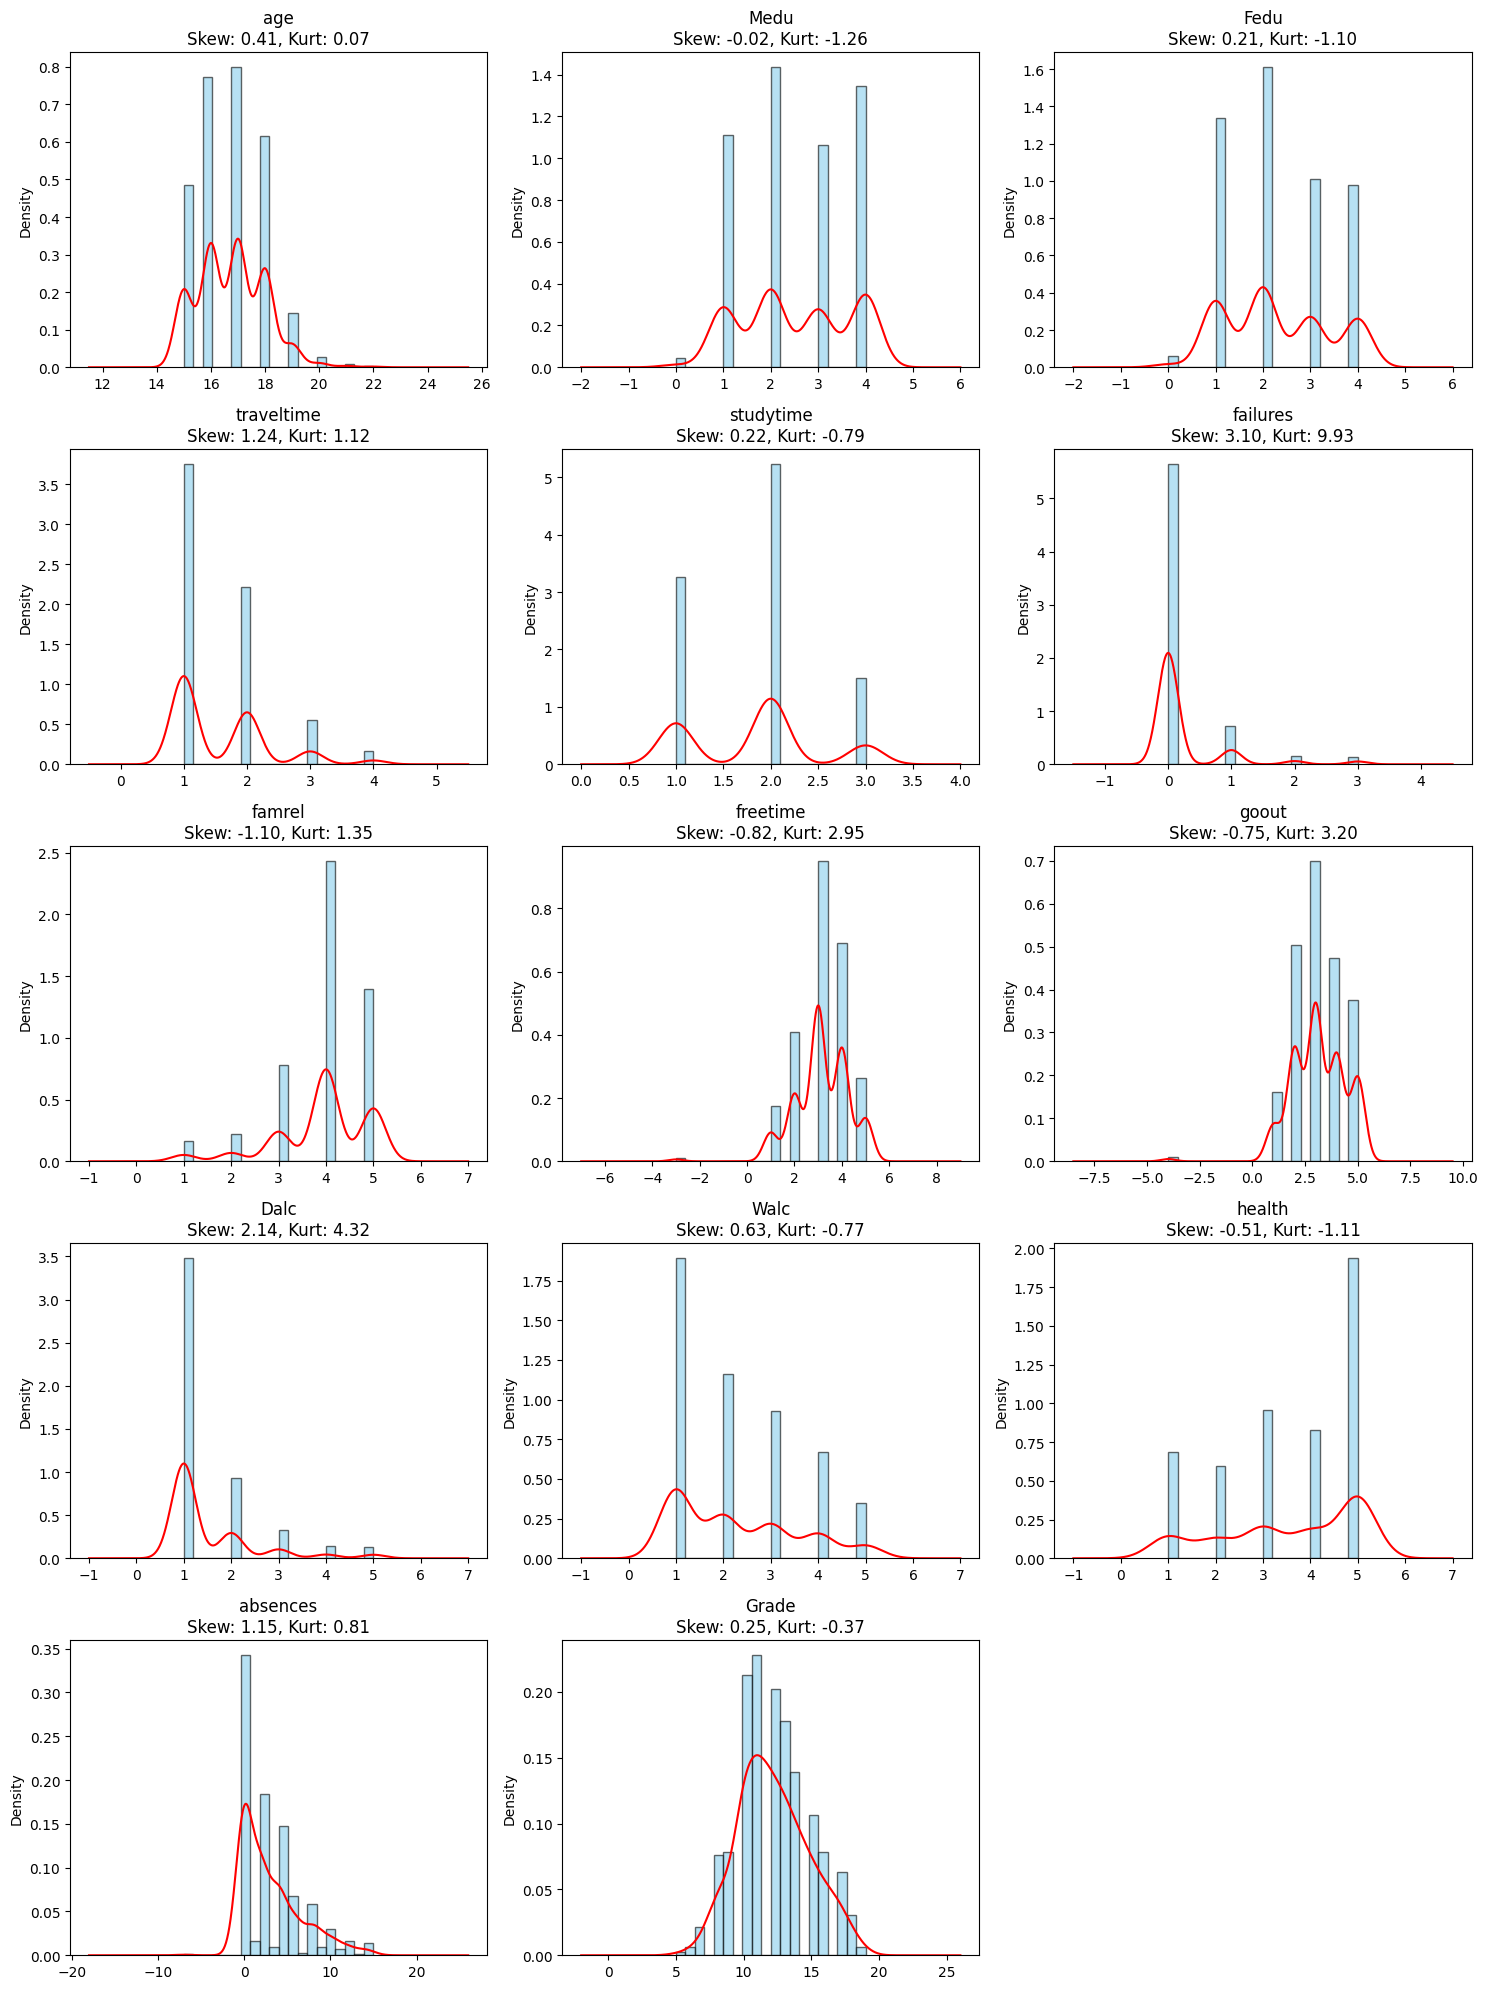

In [ ]:
# Automatically calculate the number of rows and columns
num_vars = len(numeric_cols)
rows = math.ceil(num_vars / 3)  # 3 plots per row
fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    ax.hist(df[col], bins=20, color='skyblue', edgecolor='black', density=True, alpha=0.6)
    df[col].plot(kind='kde', ax=ax, color='red')  # Kernel density curve

    # Add skewness and kurtosis to the title
    skew_val = df[col].skew()
    kurt_val = df[col].kurtosis()
    ax.set_title(f"{col}\nSkew: {skew_val:.2f}, Kurt: {kurt_val:.2f}")
    ax.set_xlabel('')
    ax.set_ylabel('Density')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()



# Identify the main patterns

## Univariate distribution

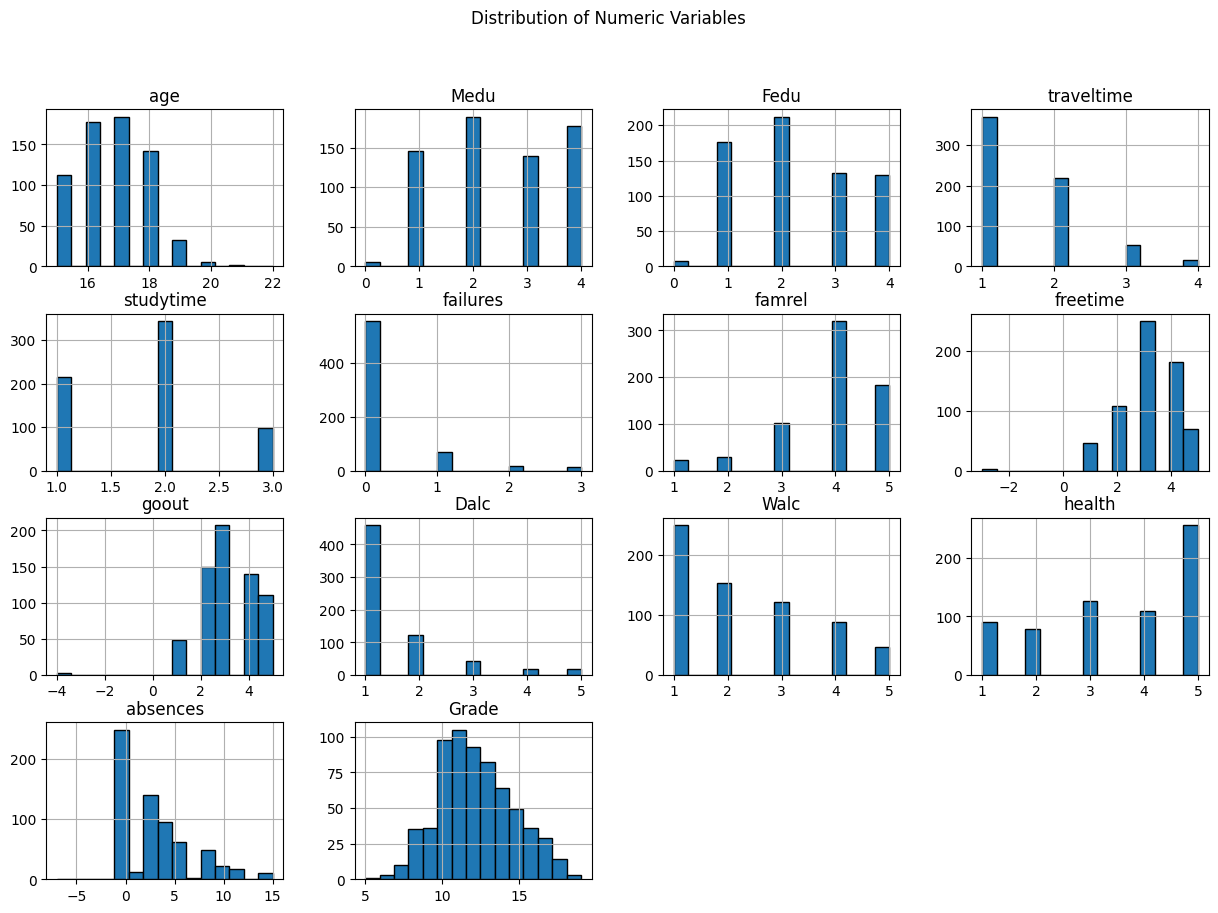

In [ ]:
# Distribution of numeric variables
df[numeric_cols].hist(bins=15, figsize=(15, 10), edgecolor='black')
plt.suptitle("Distribution of Numeric Variables")
plt.show()

## Frequency of categorical variables

/tmp/ipython-input-1341387850.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='pastel')
/tmp/ipython-input-1341387850.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='pastel')
/tmp/ipython-input-1341387850.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='pastel')
/tmp/ipython-input-1341387850.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `

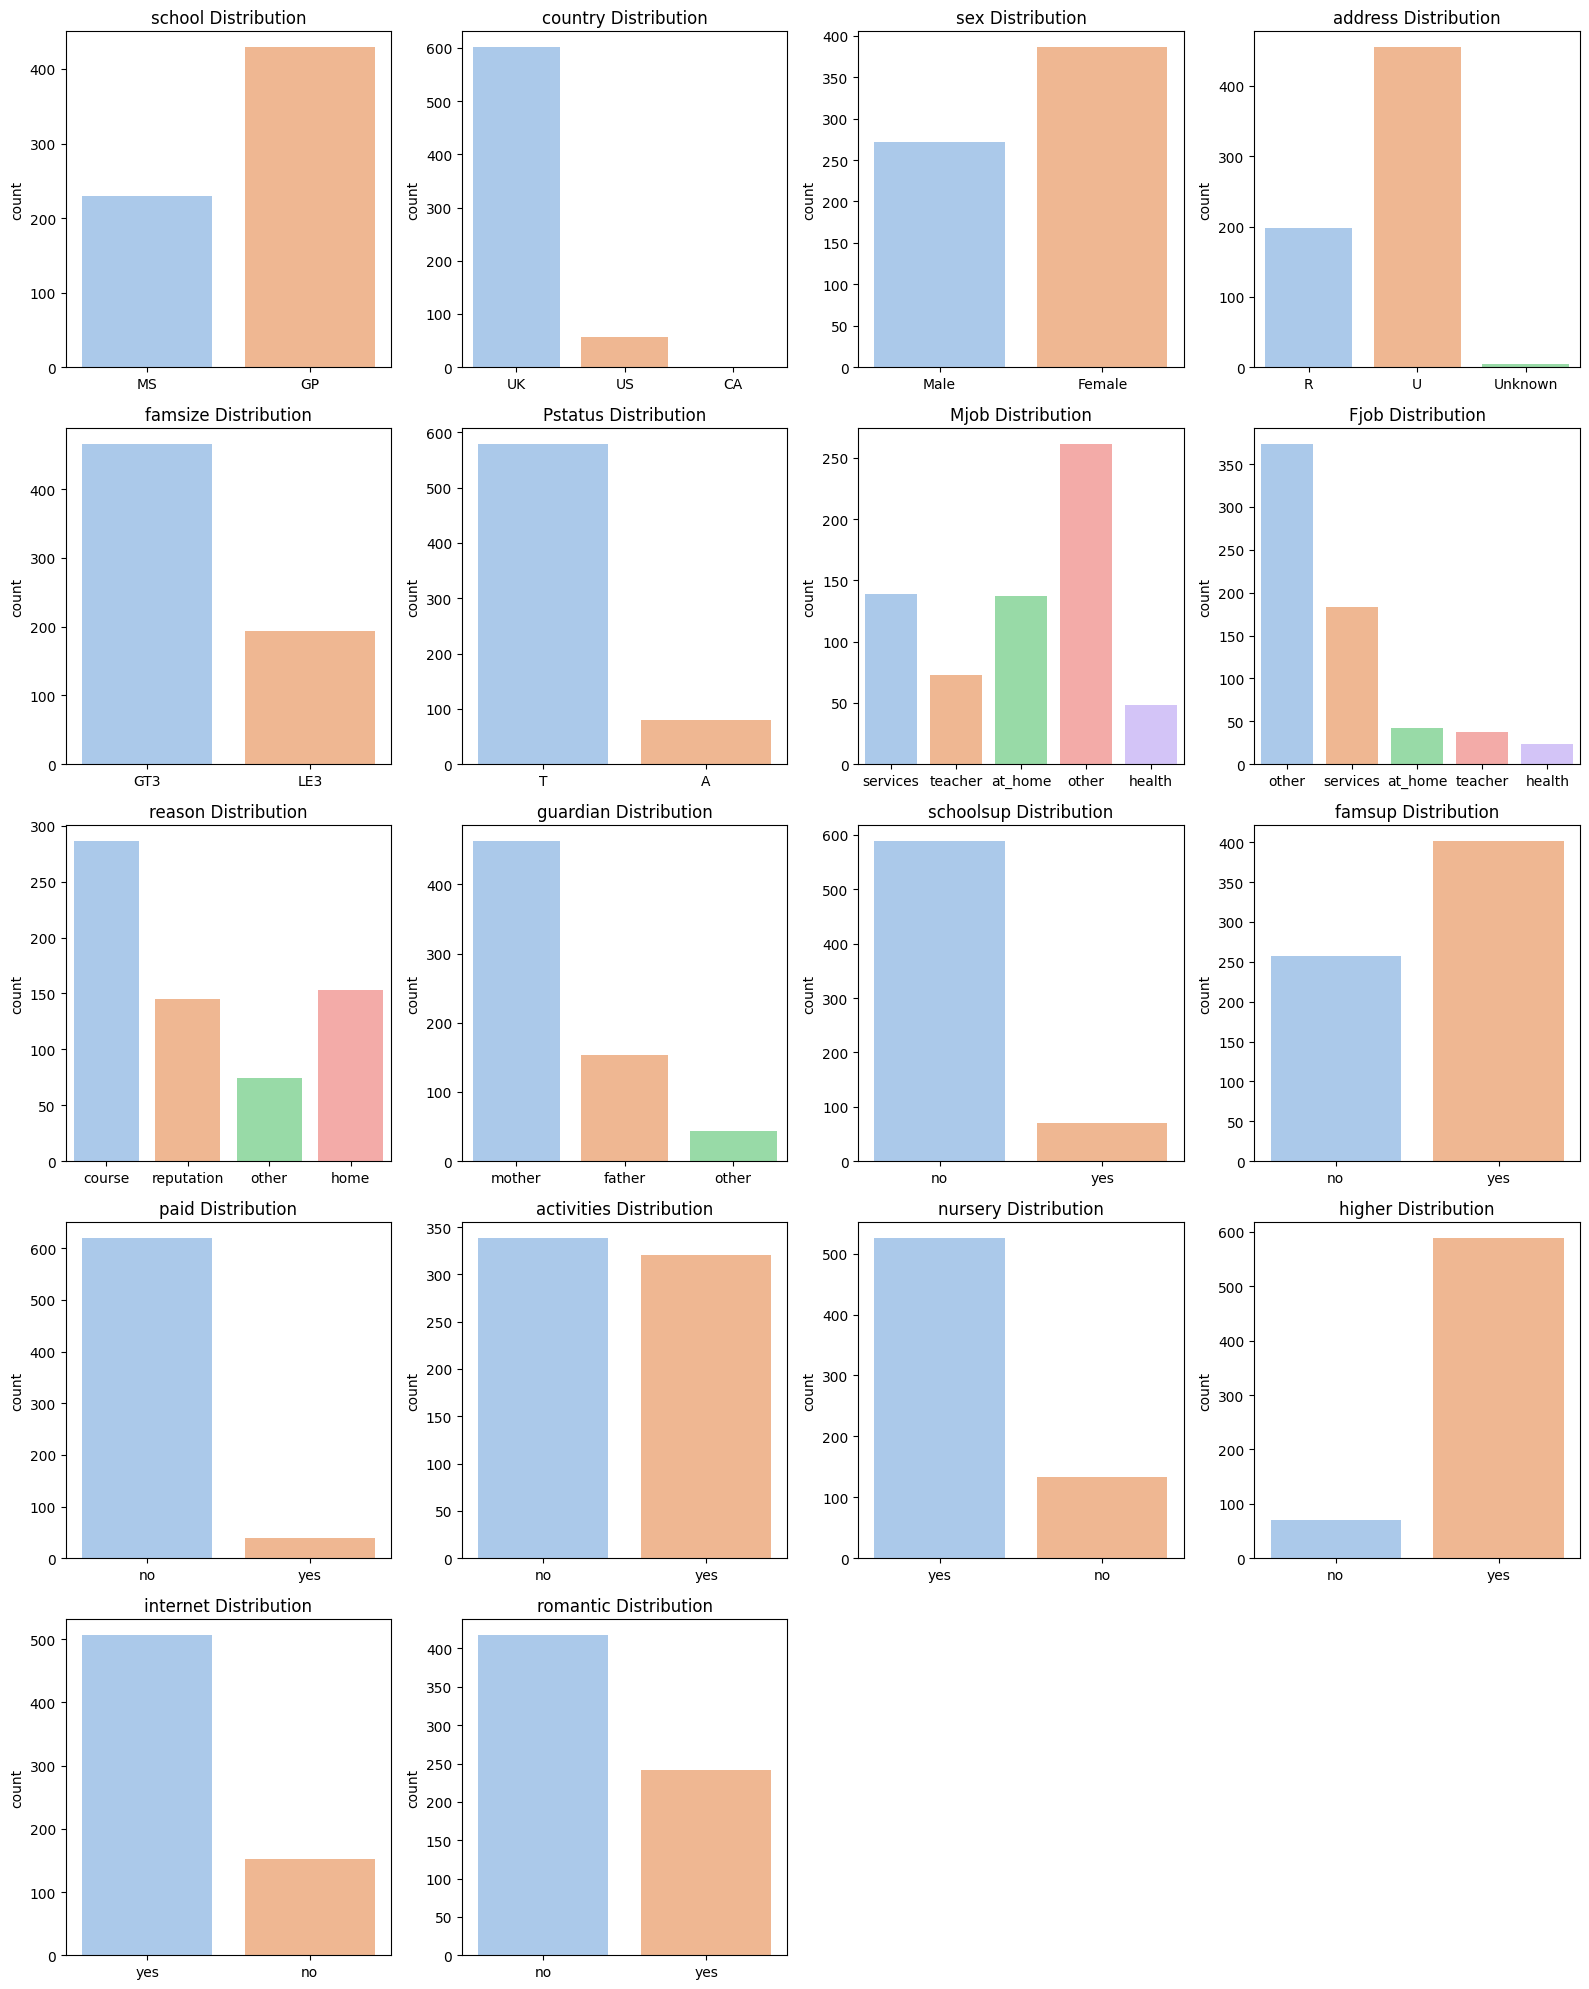

In [ ]:
# Replace values in the 'sex' column
df['sex'] = df['sex'].replace({'Ma': 'Male', 'M': 'Male', 'F': 'Female'})

# Replace values in the 'schoolsup' column
df['schoolsup'] = df['schoolsup'].replace({'n': 'no'})

# Automatically calculate the number of rows (4 plots per row)
num_cols = len(categorical_cols)
rows = math.ceil(num_cols / 4)

fig, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows))
axes = axes.flatten()  # Flatten 2D axes array for easier indexing

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='pastel')
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel("")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Heatmap

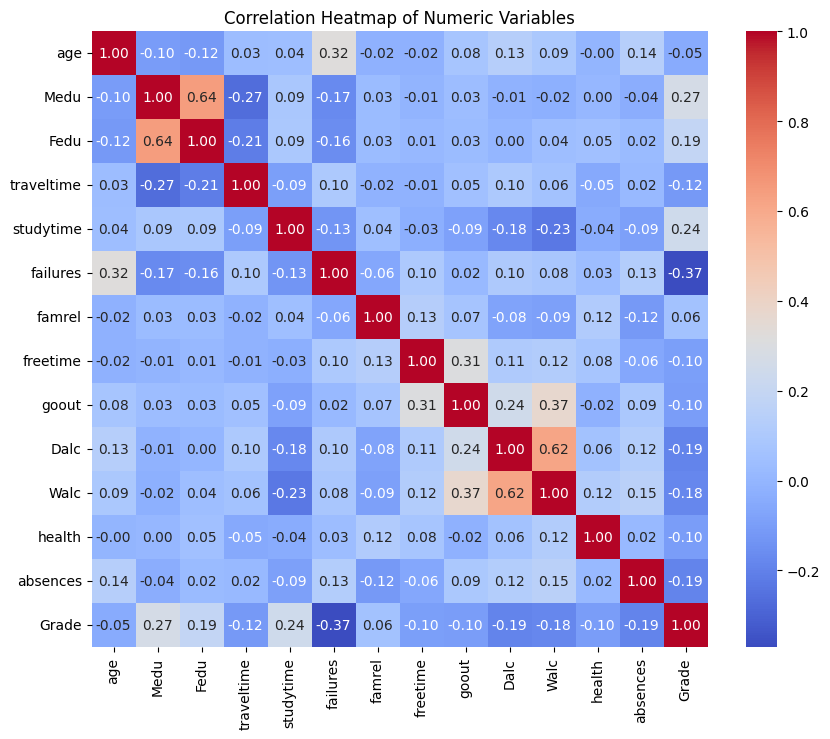

In [ ]:
# Correlation matrix for numeric variables
corr = df[numeric_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

## correlation coefficient

In [ ]:
# Correlation with Grade
corr_with_grade = corr['Grade'].sort_values(ascending=False)
print("\n===== Correlation with Grade =====")
print(corr_with_grade)


===== Correlation with Grade =====
Grade         1.000000
Medu          0.267194
studytime     0.242366
Fedu          0.187902
famrel        0.061170
age          -0.046221
freetime     -0.097497
goout        -0.099297
health       -0.102673
traveltime   -0.117190
Walc         -0.181727
Dalc         -0.190371
absences     -0.192686
failures     -0.371555
Name: Grade, dtype: float64


## Bivariate analysis: the relationship between all numerical variables and grade

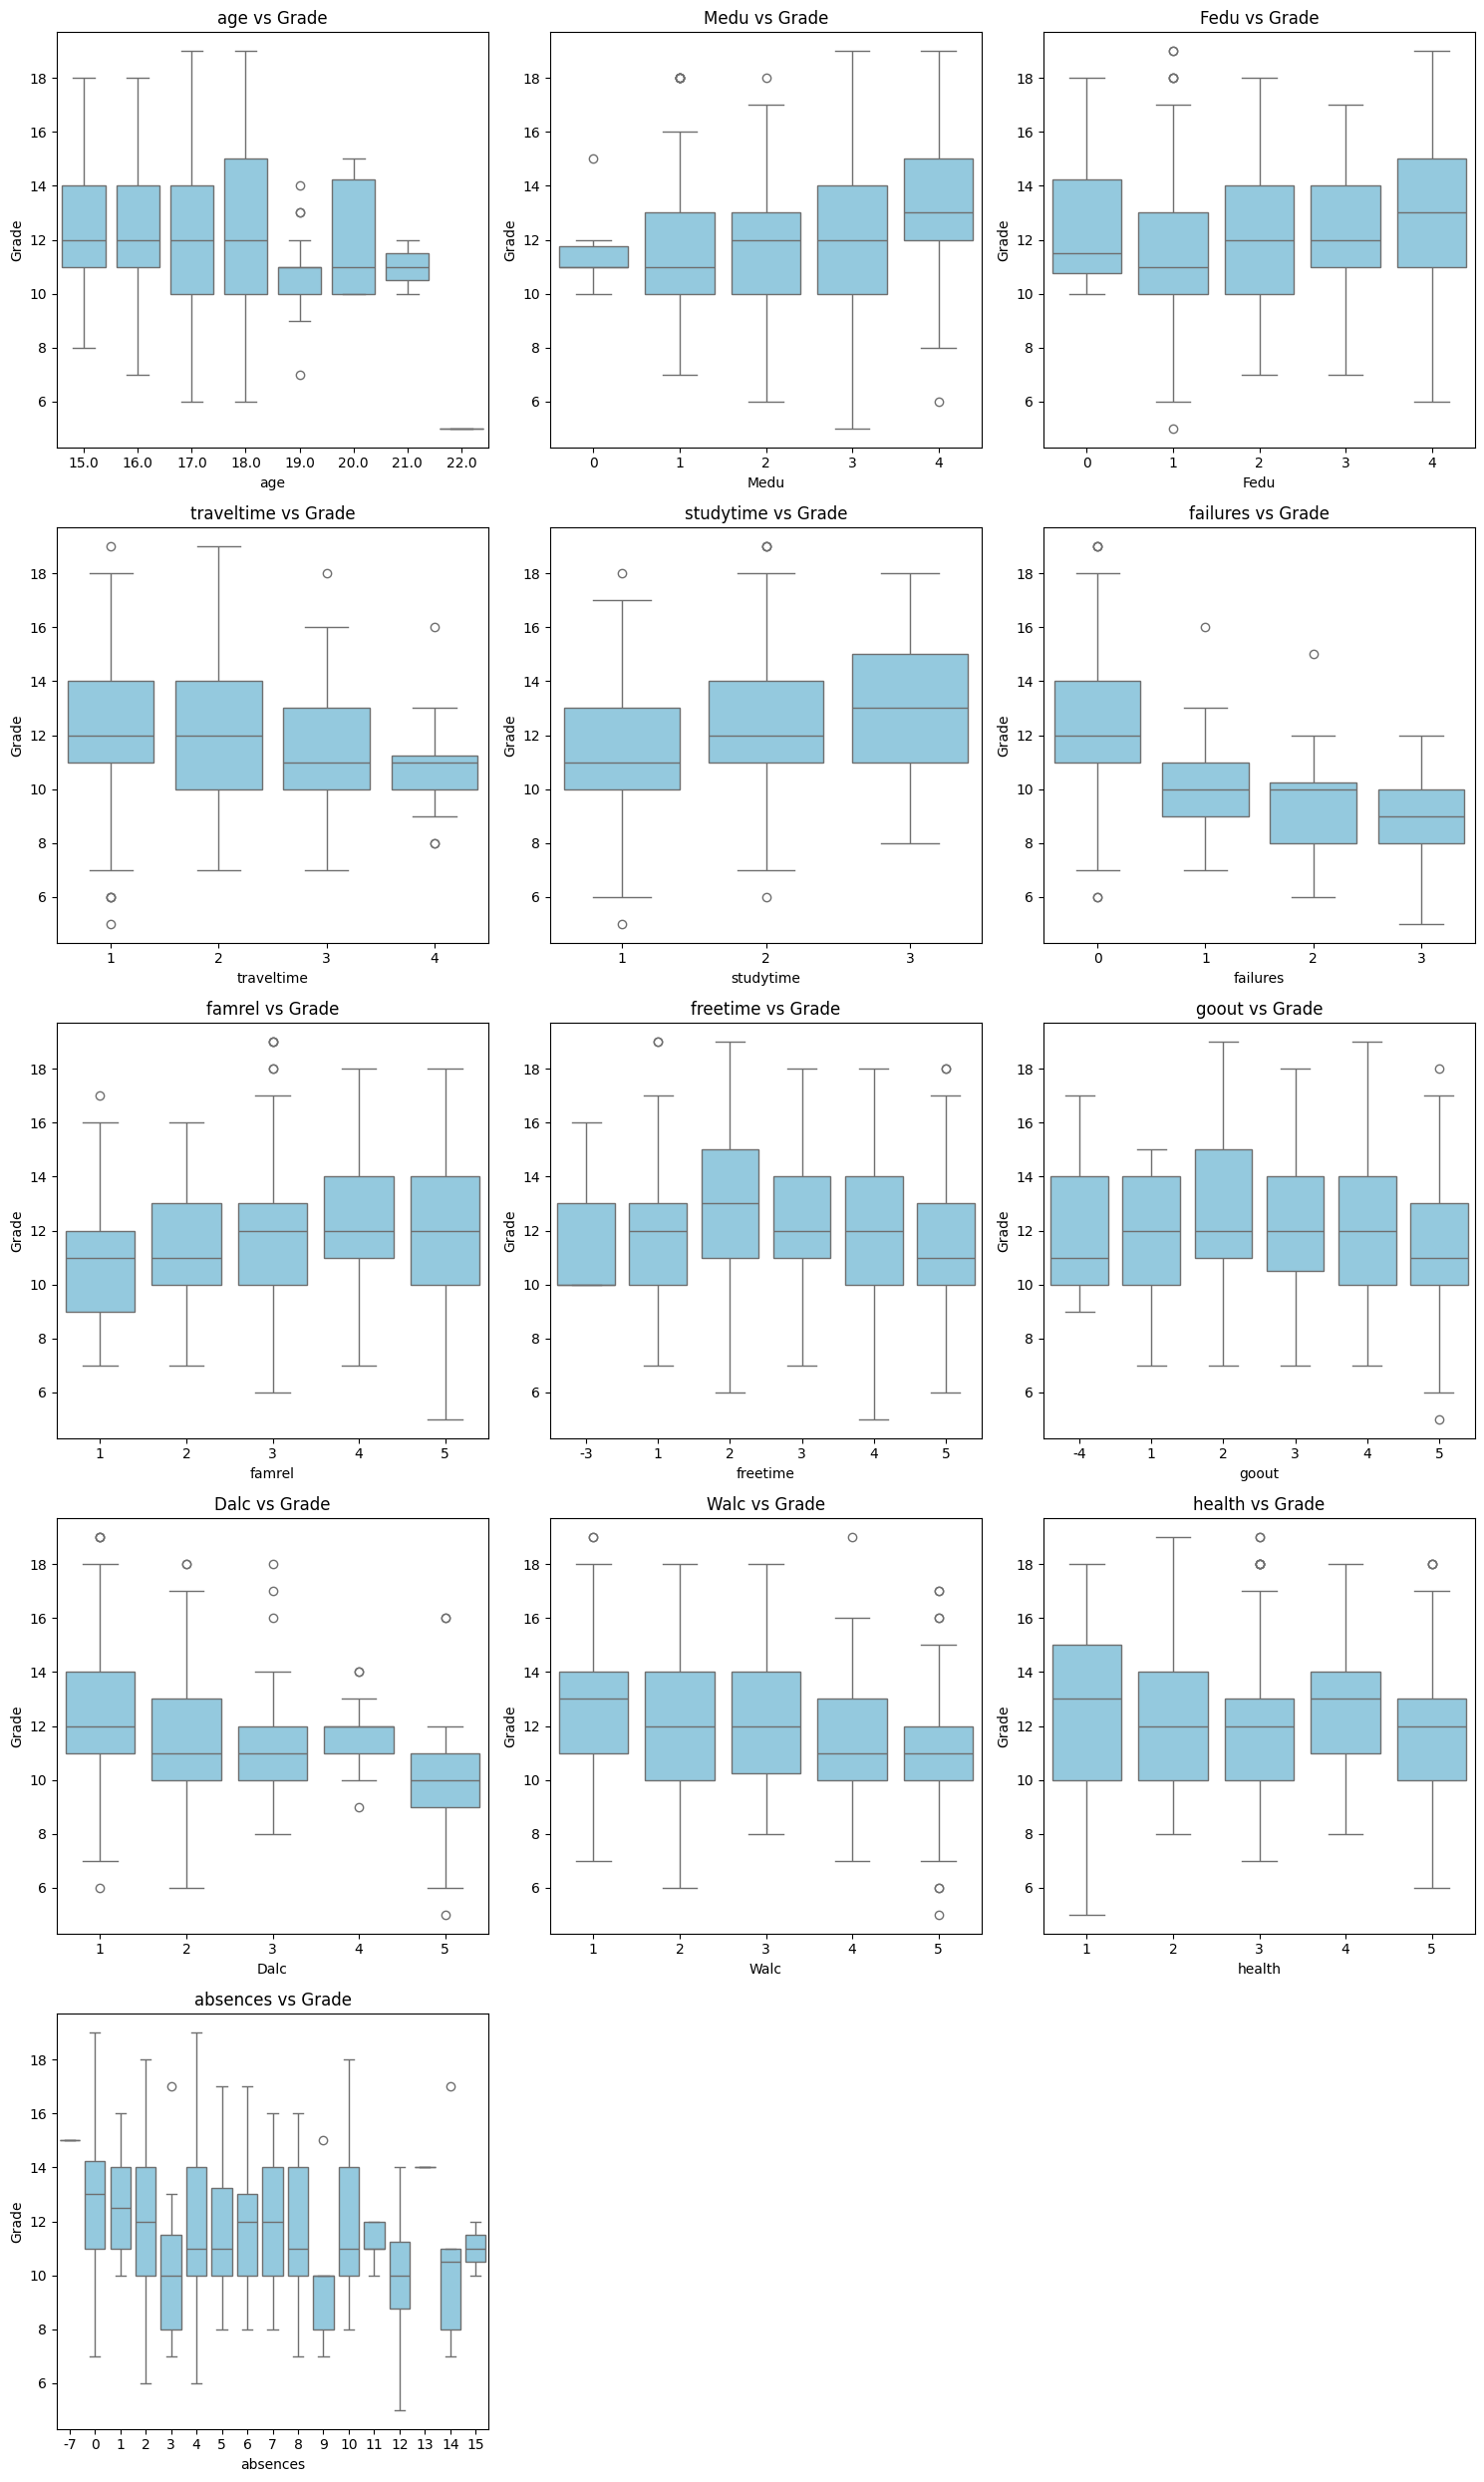

In [ ]:
# Select all numeric columns from the DataFrame
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove the target variable 'Grade' (we’ll use it on the y-axis)
numeric_cols.remove('Grade')

# Define layout: 3 plots per row
n_cols = 3
# Calculate the number of rows needed to display all numeric variables
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

# Create the figure with a dynamic height based on the number of rows
plt.figure(figsize=(15, n_rows * 5))

# Loop through each numeric column and create a boxplot
for i, col in enumerate(numeric_cols):
    # Define the subplot position (row, column, index)
    plt.subplot(n_rows, n_cols, i + 1)

    # Create a boxplot showing the relationship between each numeric variable and Grade
    sns.boxplot(data=df, x=col, y='Grade', color='skyblue')

    # Set a descriptive title for each subplot
    plt.title(f"{col} vs Grade")

# Adjust layout to prevent overlap between plots
plt.tight_layout()

# Display all the boxplots
plt.show()


In [ ]:
import pandas as pd
from scipy import stats

# --- 1. 筛选数值型变量 (基于相关系数) ---
print("===== 1. Top Numeric Features correlated with Grade =====")
# 计算所有数值列与 Grade 的相关性
numeric_corr = df.select_dtypes(include=[np.number]).corr()['Grade'].drop('Grade')
# 按绝对值排序
top_numeric = numeric_corr.abs().sort_values(ascending=False).head(5)
print(top_numeric)


# --- 2. 筛选分类型变量 (基于 Kruskal-Wallis 检验) ---
print("\n===== 2. Significant Categorical Features (Kruskal-Wallis Test) =====")
# 找出所有的分类变量 (object 类型)
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

results = []
for col in cat_cols:
    # 获取该列的所有组别
    groups = [df[df[col] == g]['Grade'] for g in df[col].unique()]

    # 只有组别数量 > 1 才能做检验
    if len(groups) > 1:
        stat, p = stats.kruskal(*groups)
        results.append({'Feature': col, 'P-Value': p})

# 将结果转为 DataFrame 并按 P 值排序
res_df = pd.DataFrame(results).sort_values(by='P-Value')

# 打印显著的特征 (P < 0.05)
significant_cats = res_df[res_df['P-Value'] < 0.05]
print(f"Found {len(significant_cats)} significant categorical features:")
print(significant_cats)

print("\n[建议]")
print(f"你应该重点分析数值变量: {top_numeric.index.tolist()}")
print(f"以及排名靠前的分类变量: {significant_cats['Feature'].head(3).tolist()}")

===== 1. Top Numeric Features correlated with Grade =====
failures     0.371555
Medu         0.267194
studytime    0.242366
absences     0.192686
Dalc         0.190371
Name: Grade, dtype: float64

===== 2. Significant Categorical Features (Kruskal-Wallis Test) =====
Found 12 significant categorical features:
       Feature       P-Value
15      higher  1.034014e-17
0       school  3.279023e-10
6         Mjob  2.850638e-07
8       reason  1.974728e-06
16    internet  6.529084e-04
7         Fjob  7.949906e-04
2          sex  2.058810e-03
3      address  2.647149e-03
10   schoolsup  9.901019e-03
9     guardian  1.428386e-02
13  activities  2.620671e-02
14     nursery  4.474625e-02

[建议]
你应该重点分析数值变量: ['failures', 'Medu', 'studytime', 'absences', 'Dalc']
以及排名靠前的分类变量: ['higher', 'school', 'Mjob']


# Hypothesis testing

### 1.Kruskal-Wallis H Test + Shapiro–Wilk Test

In [ ]:
# Kruskal-Wallis H Test (Non-parametric alternative to ANOVA)
print("\n===== Kruskal-Wallis Test: Study Time vs Grade =====")

# devide in group
groups_data = [df[df['studytime'] == g]['Grade'] for g in sorted(df['studytime'].unique())]

# test
stat, p_val = stats.kruskal(*groups_data)

print(f"H-statistic = {stat:.3f}, p-value = {p_val:.4f}")

# result
if p_val < 0.05:
    print("Significant difference found among study time groups (Reject H0).")
    print("Conclusion: There are significant differences in the distribution of scores between groups with different learning times.")

    # Post-hoc Analysis
    print("\n Pairwise Comparisons (Mann-Whitney U with Bonferroni Correction)")
    import itertools

    unique_groups = sorted(df['studytime'].unique())
    combinations = list(itertools.combinations(unique_groups, 2))

    # Bonferroni Correction: Significance level alpha / Number of comparisons
    alpha = 0.05 / len(combinations)
    print(f"Bonferroni Corrected Alpha: {alpha:.4f}")

    for g1, g2 in combinations:
        data1 = df[df['studytime'] == g1]['Grade']
        data2 = df[df['studytime'] == g2]['Grade']
        _, p_pair = stats.mannwhitneyu(data1, data2)

        sig = "*" if p_pair < alpha else " "
        print(f"Group {g1} vs {g2}: p={p_pair:.4f} {sig}")

else:
    print("No significant difference found (Fail to reject H0).")
    print("Conclusion: The length of study time does not have a significant impact on grades.")


===== Kruskal-Wallis Test: Study Time vs Grade =====
H-statistic = 41.550, p-value = 0.0000
Significant difference found among study time groups (Reject H0).
Conclusion: There are significant differences in the distribution of scores between groups with different learning times.

 Pairwise Comparisons (Mann-Whitney U with Bonferroni Correction)
Bonferroni Corrected Alpha: 0.0167
Group 1 vs 2: p=0.0000 *
Group 1 vs 3: p=0.0000 *
Group 2 vs 3: p=0.0201  


In [ ]:
from scipy import stats
import pandas as pd

# prepare data(eg: studytime)
groups_data = [df[df['studytime'] == g]['Grade'] for g in sorted(df['studytime'].unique())]

print("Sensitivity Analysis")
print(f"Comparison Groups: Study Time (Groups: {sorted(df['studytime'].unique())})")

# Kruskal-Wallis
kw_stat, kw_p = stats.kruskal(*groups_data)
print(f"\n[Primary Test] Kruskal-Wallis H Test:")
print(f"  Statistic={kw_stat:.3f}, P-value={kw_p:.4f}")
print(f"  -> {'Significant' if kw_p < 0.05 else 'Not Significant'}")

# ANOVA
anova_stat, anova_p = stats.f_oneway(*groups_data)
print(f"\n[Robustness Check] One-way ANOVA:")
print(f"  Statistic={anova_stat:.3f}, P-value={anova_p:.4f}")
print(f"  -> {'Significant' if anova_p < 0.05 else 'Not Significant'}")

# Conclusion compare
print("\nConclusion")
if (kw_p < 0.05) and (anova_p < 0.05):
    print("Both test results are consistent and significant.")
elif (kw_p < 0.05) != (anova_p < 0.05):
    print("The results of the two tests were inconsistent.")
else:
    print("Both test results were consistent (neither was statistically significant).")

Sensitivity Analysis
Comparison Groups: Study Time (Groups: [np.int64(1), np.int64(2), np.int64(3)])

[Primary Test] Kruskal-Wallis H Test:
  Statistic=41.550, P-value=0.0000
  -> Significant

[Robustness Check] One-way ANOVA:
  Statistic=21.448, P-value=0.0000
  -> Significant

Conclusion
Both test results are consistent and significant.


Start analyzing the grouping variables: ['higher', 'school', 'Mjob', 'failures', 'Medu', 'studytime', 'Dalc']


Feature Analysis: [ higher ]
1. Kruskal–Wallis Test (p-value): 0.00000
2. One-way ANOVA       (p-value): 0.00000
-> Conclusion: [Significant Effect]. Differences in Grade across 'higher' groups are statistically significant.

Feature Analysis: [ school ]
1. Kruskal–Wallis Test (p-value): 0.00000
2. One-way ANOVA       (p-value): 0.00000
-> Conclusion: [Significant Effect]. Differences in Grade across 'school' groups are statistically significant.

Feature Analysis: [ Mjob ]
1. Kruskal–Wallis Test (p-value): 0.00000
2. One-way ANOVA       (p-value): 0.00000
-> Conclusion: [Significant Effect]. Differences in Grade across 'Mjob' groups are statistically significant.

Feature Analysis: [ failures ]
1. Kruskal–Wallis Test (p-value): 0.00000
2. One-way ANOVA       (p-value): 0.00000
-> Conclusion: [Significant Effect]. Differences in Grade across 'failures' groups are statisticall

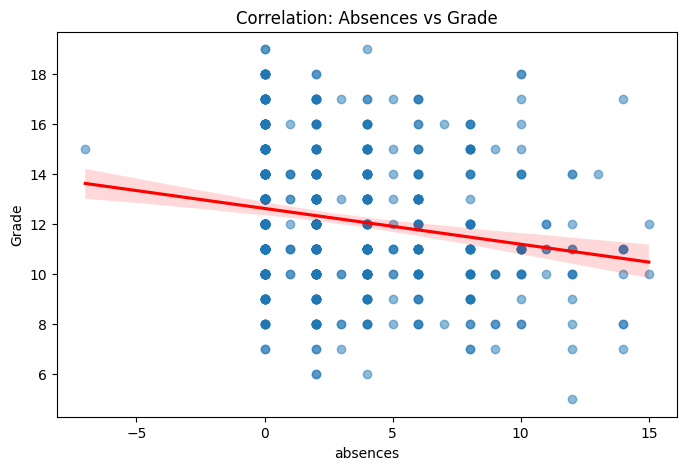

Pearson Correlation (linear): -0.193
Spearman Correlation (rank-based): -0.199
-> Conclusion: Negative correlation. More absences tend to be associated with lower grades.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd

# Define the list of "group-type" features to be analyzed.
group_features = ['higher', 'school', 'Mjob', 'failures', 'Medu', 'studytime', 'Dalc']

print(f"Start analyzing the grouping variables: {group_features}\n")

for feature in group_features:
    print(f"\n{'='*60}")
    print(f"Feature Analysis: [ {feature} ]")

    # Prepare data
    # Sort groups in natural order
    groups = df[feature].unique()
    if len(groups) > 20:  # Prevent excessive number of groups (defensive)
        print(f"Too many groups ({len(groups)}). Skipping ANOVA. Consider correlation analysis instead.")
        continue

    group_data = [df[df[feature] == g]['Grade'] for g in sorted(groups)]

    # # 2. Visualization: Boxplot
    # plt.figure(figsize=(8, 4))
    # # If group labels are strings, sort by median Grade; if numeric, sort by value
    # if df[feature].dtype == 'object':
    #     order = df.groupby(feature)['Grade'].median().sort_values(ascending=False).index
    # else:
    #     order = sorted(df[feature].unique())
    #
    # sns.boxplot(x=feature, y='Grade', data=df, order=order, palette='viridis')
    # plt.title(f'Grade Distribution by {feature}')
    # plt.show()

    # 3. Perform dual tests
    # (1) Kruskal-Wallis (non-parametric, main reference)
    kw_stat, kw_p = stats.kruskal(*group_data)

    # (2) One-way ANOVA (parametric, robustness check)
    try:
        anova_stat, anova_p = stats.f_oneway(*group_data)
    except:
        anova_p = 1.0  # If error occurs (e.g., group too small), skip ANOVA

    # 4. Output results
    print(f"1. Kruskal–Wallis Test (p-value): {kw_p:.5f}")
    print(f"2. One-way ANOVA       (p-value): {anova_p:.5f}")

    if kw_p < 0.05:
        print(f"-> Conclusion: [Significant Effect]. Differences in Grade across '{feature}' groups are statistically significant.")
    else:
        print(f"-> Conclusion: [No Significant Effect].")


# ==========================================
# Second Part: Continuous Variable Analysis
# For absences (number of missed classes)
# ==========================================
print(f"\n{'='*60}")
print(f"Feature Analysis: [ absences ] (continuous variable)")

# 1. Visualization: Scatterplot + Regression Line
plt.figure(figsize=(8, 5))
sns.regplot(x='absences', y='Grade', data=df, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title('Correlation: Absences vs Grade')
plt.show()

# 2. Compute correlation coefficients
corr_pearson, _ = stats.pearsonr(df['absences'], df['Grade'])
corr_spearman, _ = stats.spearmanr(df['absences'], df['Grade'])

print(f"Pearson Correlation (linear): {corr_pearson:.3f}")
print(f"Spearman Correlation (rank-based): {corr_spearman:.3f}")

if corr_spearman < -0.1:
    print("-> Conclusion: Negative correlation. More absences tend to be associated with lower grades.")
elif corr_spearman > 0.1:
    print("-> Conclusion: Positive correlation (rare).")
else:
    print("-> Conclusion: Very weak or no correlation.")


### 2.t-test

In [ ]:
# Preliminary statistical analysis
# Example 1: Compare grade by gender (t-test)
male_grades = df[df['sex'] == 'Male']['Grade']
female_grades = df[df['sex'] == 'Female']['Grade']

t_stat, p_val = stats.ttest_ind(male_grades, female_grades, nan_policy='omit')
print("\n===== T-test: Male vs Female Grades =====")
print(f"T-statistic = {t_stat:.3f}, p-value = {p_val:.4f}")
if p_val < 0.05:
    print("→ Significant difference between male and female grades.")
else:
    print("→ No significant difference between male and female grades.")


===== T-test: Male vs Female Grades =====
T-statistic = -3.030, p-value = 0.0025
→ Significant difference between male and female grades.


In [ ]:
# Independent t-test for Grade between two schools
school_gp_grades = df[df['school'] == 'GP']['Grade']
school_ms_grades = df[df['school'] == 'MS']['Grade']

t_stat_school, p_val_school = stats.ttest_ind(school_gp_grades, school_ms_grades, nan_policy='omit')

print("\n===== Independent t-test: GP School vs MS School Grades =====")
print(f"T-statistic = {t_stat_school:.3f}, p-value = {p_val_school:.4f}")

if p_val_school < 0.05:
    print("→ Significant difference in grades between GP and MS schools.")
else:
    print("→ No significant difference in grades between GP and MS schools.")


===== Independent t-test: GP School vs MS School Grades =====
T-statistic = 5.877, p-value = 0.0000
→ Significant difference in grades between GP and MS schools.


In [ ]:
# 1. Shapiro-Wilk Test for Normality
# Check the overall distribution of Grade and the group-wise distributions
print("===== Shapiro-Wilk Test for Normality =====")

# Overall Grade
stat, p = stats.shapiro(df['Grade'])
print(f"Overall Grade: Statistics={stat:.3f}, p={p:.3f}")
if p > 0.05:
    print("-> Data appears to be normally distributed (fail to reject H0)")
else:
    print("-> Data does NOT appear to be normally distributed (reject H0)")

# Check normality within each study time group
print("\n--- Normality by Study Time Groups ---")
groups = df['studytime'].unique()
groups.sort()
for g in groups:
    group_data = df[df['studytime'] == g]['Grade']
    stat, p = stats.shapiro(group_data)
    print(f"StudyTime {g}: p={p:.3f} ({'Normal' if p > 0.05 else 'Not Normal'})")


===== Shapiro-Wilk Test for Normality =====
Overall Grade: Statistics=0.977, p=0.000
-> Data does NOT appear to be normally distributed (reject H0)

--- Normality by Study Time Groups ---
StudyTime 1: p=0.000 (Not Normal)
StudyTime 2: p=0.000 (Not Normal)
StudyTime 3: p=0.023 (Not Normal)


### 3.Chi-squared test

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np

print("===== Chi-square Test Analysis =====")

# --- Step 1: Prepare data (Convert numeric Grade into a categorical variable) ---
# Chi-square test requires both variables to be categorical.
# According to the Portuguese grading scale (0–20), we categorize:
# 0–9: Fail
# 10–20: Pass
# (You may refine bins further if needed: 0–9, 10–13, 14–15, 16–20)

# Here we create a simple binary target variable "Pass_Status"
df['Pass_Status'] = pd.cut(df['Grade'], bins=[-1, 9, 20], labels=['Fail', 'Pass'])
print("1. Created new categorical target 'Pass_Status' (Fail/Pass) from 'Grade'.")


# --- Step 2: Define the categorical variables to analyze ---
# You may add or remove variables depending on your needs
categorical_features = [
    'sex',          # gender
    'school',       # school type
    'address',      # urban/rural
    'famsize',      # family size
    'Pstatus',      # parent's cohabitation status
    'Mjob',         # mother's job
    'Fjob',         # father's job
    'reason',       # reason for choosing the school
    'guardian',     # legal guardian
    'schoolsup',    # school support
    'famsup',       # family support
    'paid',         # extra paid classes
    'activities',   # extra-curricular activities
    'nursery',      # attended nursery school
    'higher',       # desire for higher education
    'internet',     # internet access at home
    'romantic'      # romantic relationship
]

print(f"2. Analyzing {len(categorical_features)} categorical features against 'Pass_Status'...\n")


# --- Step 3: Perform Chi-square tests in batch ---
chi2_results = []

for feature in categorical_features:

    # 1. Create contingency table
    contingency_table = pd.crosstab(df[feature], df['Pass_Status'])

    # 2. Apply Chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # 3. Compute Cramer's V (effect size)
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    cramer_v = np.sqrt(chi2 / (n * min_dim))

    chi2_results.append({
        'Feature': feature,
        'P-Value': p,
        "Cramer's V": cramer_v,
        'Significant': 'Yes' if p < 0.05 else 'No'
    })


# --- Step 4: Display the results ---
results_df = pd.DataFrame(chi2_results).sort_values(by='P-Value')

print("===== Chi-square Test Results (Association with Passing) =====")
print(results_df)

# Print significant features
print("\n[Significant Variables (P < 0.05)]:")
significant_vars = results_df[results_df['Significant'] == 'Yes']['Feature'].tolist()
print(significant_vars)

if not significant_vars:
    print("No categorical variables show a statistically significant association with passing status.")
else:
    print(f"\nInterpretation Suggestion: Variables {significant_vars} have a statistically significant association with pass/fail outcomes.")
    print("You can visualize these associations using stacked bar charts for clearer interpretation.")


===== Chi-square Test Analysis =====
1. Created new categorical target 'Pass_Status' (Fail/Pass) from 'Grade'.
2. Analyzing 17 categorical features against 'Pass_Status'...

===== Chi-square Test Results (Association with Passing) =====
       Feature       P-Value  Cramer's V Significant
14      higher  3.450750e-12    0.271252         Yes
1       school  5.340840e-09    0.227518         Yes
7       reason  2.503254e-03    0.147510         Yes
5         Mjob  3.729665e-02    0.124463         Yes
8     guardian  7.124429e-02    0.089606          No
2      address  1.279382e-01    0.079056          No
0          sex  1.331140e-01    0.058552          No
12  activities  1.746251e-01    0.052921          No
15    internet  1.797340e-01    0.052300          No
11        paid  2.255541e-01    0.047244          No
16    romantic  2.919987e-01    0.041079          No
3      famsize  5.347413e-01    0.024201          No
6         Fjob  6.431391e-01    0.061742          No
9    schoolsup  8.379

### 4.Cohen’s d: Evaluate the effect size and real-world impact of group difference



In [ ]:
import numpy as np
import pandas as pd

print("===== Cohen's d Effect Size Analysis =====")

# 1. Define function to compute Cohen’s d
def calculate_cohens_d(group1, group2):
    """Compute Cohen's d effect size between two groups."""
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)

    # Compute pooled standard deviation
    pooled_se = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))

    # Compute Cohen's d
    d = (np.mean(group1) - np.mean(group2)) / pooled_se
    return d


# 2. Define list of binary features to analyze
binary_features = [
    'school', 'sex', 'address', 'famsize', 'Pstatus',
    'schoolsup', 'famsup', 'paid', 'activities',
    'nursery', 'higher', 'internet', 'romantic'
]

results = []

# 3. Batch compute Cohen’s d for each binary feature
for feature in binary_features:
    groups = df[feature].unique()

    # Ensure the variable has exactly two categories
    if len(groups) == 2:
        group1_name = groups[0]
        group2_name = groups[1]

        data1 = df[df[feature] == group1_name]['Grade']
        data2 = df[df[feature] == group2_name]['Grade']

        # Compute Cohen's d
        d_val = calculate_cohens_d(data1, data2)

        # Interpret effect size according to Cohen (1988)
        abs_d = abs(d_val)
        if abs_d < 0.2:
            impact = "Negligible"
        elif abs_d < 0.5:
            impact = "Small"
        elif abs_d < 0.8:
            impact = "Medium"
        else:
            impact = "Large"

        results.append({
            'Feature': feature,
            'Comparison': f"{group1_name} vs {group2_name}",
            'Mean_1': round(data1.mean(), 2),
            'Mean_2': round(data2.mean(), 2),
            'Cohen\'s d': d_val,
            'Abs_d': abs_d,  # used for sorting
            'Real-world Impact': impact
        })

# 4. Display results (sorted by effect size magnitude)
results_df = pd.DataFrame(results).sort_values(by='Abs_d', ascending=False).drop(columns=['Abs_d'])

print("Effect Size Ranking for Each Variable:")
print(results_df)


===== Cohen's d Effect Size Analysis =====
Effect Size Ranking for Each Variable:
       Feature      Comparison  Mean_1  Mean_2  Cohen's d Real-world Impact
9       higher       no vs yes    9.69   12.49  -1.135965             Large
0       school        MS vs GP   11.39   12.62  -0.480961             Small
4    schoolsup       no vs yes   12.28   11.43   0.328492             Small
10    internet       yes vs no   12.36   11.63   0.280876             Small
6         paid       no vs yes   12.24   11.51   0.276825             Small
1          sex  Male vs Female   11.83   12.45  -0.239892             Small
8      nursery       yes vs no   12.29   11.82   0.179287        Negligible
7   activities       no vs yes   12.00   12.40  -0.152062        Negligible
11    romantic       no vs yes   12.28   12.05   0.088920        Negligible
2      famsize      GT3 vs LE3   12.15   12.29  -0.052533        Negligible
5       famsup       no vs yes   12.17   12.21  -0.013668        Negligible
3     

# Confidence Interval


In [ ]:
import numpy as np
import scipy.stats as stats
import math

print("===== 95% Confidence Intervals Analysis =====")

# --- 1. Functions to compute confidence intervals ---

def get_mean_ci(data, confidence=0.95):
    """Compute the confidence interval for the mean of a numeric variable."""
    n = len(data)
    m, se = np.mean(data), stats.sem(data)  # sem: standard error of the mean
    h = se * stats.t.ppf((1 + confidence) / 2., n - 1)
    return m, m - h, m + h

def get_proportion_ci(data, target_label, confidence=0.95):
    """Compute the confidence interval for a proportion (normal approximation)."""
    n = len(data)
    p = (data == target_label).sum() / n
    # Standard error: sqrt(p*(1-p)/n)
    se = math.sqrt(p * (1 - p) / n)
    # Z-score for 95% CI ≈ 1.96
    z = stats.norm.ppf((1 + confidence) / 2.)
    h = z * se
    return p, p - h, p + h


# --- 2. Run the analysis ---

print(f"Total sample size (N) = {len(df)}")

# (1) Estimate the population mean Grade
mean_val, lower, upper = get_mean_ci(df['Grade'])
print(f"\n[1] Mean Grade:")
print(f"   - Sample Mean: {mean_val:.2f}")
print(f"   - 95% CI: [{lower:.2f}, {upper:.2f}]")
print(f"   -> Interpretation: We are 95% confident that the true population mean Grade lies between {lower:.2f} and {upper:.2f}.")

# (2) Estimate the mean number of absences
mean_val, lower, upper = get_mean_ci(df['absences'])
print(f"\n[2] Mean Absences:")
print(f"   - Sample Mean: {mean_val:.2f}")
print(f"   - 95% CI: [{lower:.2f}, {upper:.2f}]")

# (3) Estimate the pass rate (Grade ≥ 10)
df['is_pass'] = df['Grade'].apply(lambda x: 'yes' if x >= 10 else 'no')
prop, lower, upper = get_proportion_ci(df['is_pass'], 'yes')
print(f"\n[3] Pass Rate:")
print(f"   - Sample Proportion: {prop:.2%}")
print(f"   - 95% CI: [{lower:.2%}, {upper:.2%}]")
print(f"   -> Interpretation: We estimate that the true school-wide pass rate is between {lower:.1%} and {upper:.1%}.")

# (4) Estimate the proportion of students who desire higher education
prop, lower, upper = get_proportion_ci(df['higher'], 'yes')
print(f"\n[4] Higher Education Aspiration Rate:")
print(f"   - Sample Proportion: {prop:.2%}")
print(f"   - 95% CI: [{lower:.2%}, {upper:.2%}]")
